In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
news_df = pd.read_csv("../data/news_dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
news_df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [4]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [5]:
news_df.describe(include="all")

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


In [6]:
news_df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [7]:
news_df.duplicated().sum()

np.int64(209)

In [8]:
news_df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

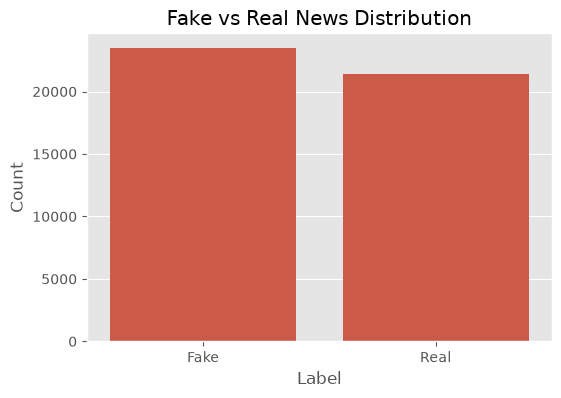

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=news_df)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks([0,1],["Fake","Real"])

plt.show()

In [10]:
news_df["text_length"] = news_df["text"].apply(len)

news_df["text_length"].describe()

count    44898.000000
mean      2469.109693
std       2171.617091
min          1.000000
25%       1234.000000
50%       2186.000000
75%       3105.000000
max      51794.000000
Name: text_length, dtype: float64

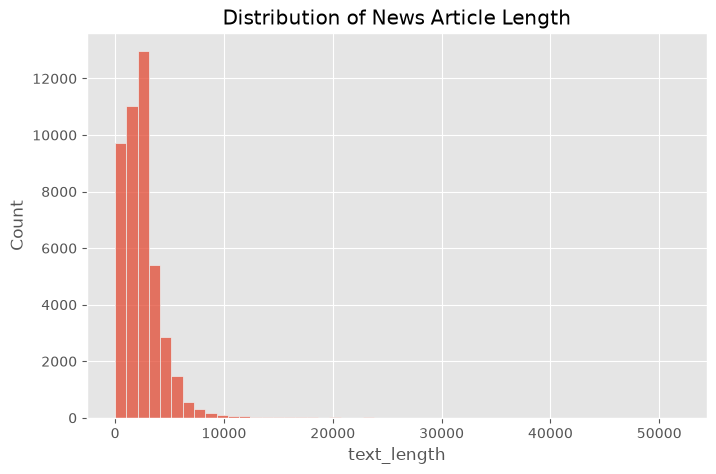

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(news_df["text_length"], bins=50)

plt.title("Distribution of News Article Length")

plt.show()

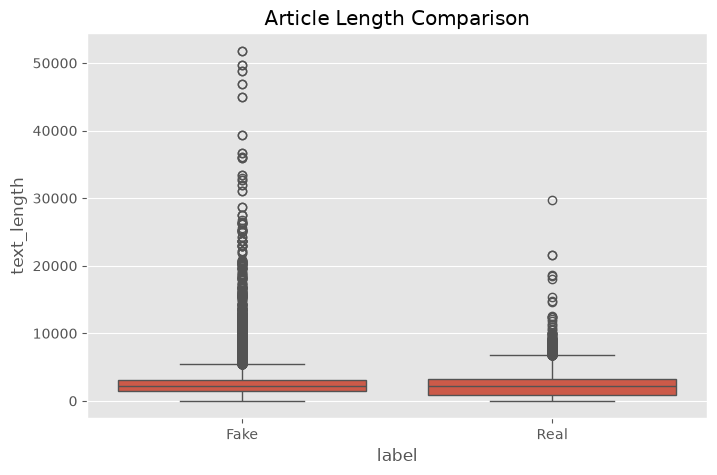

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="label", y="text_length", data=news_df)

plt.xticks([0,1],["Fake","Real"])

plt.title("Article Length Comparison")

plt.show()

In [13]:
news_df["subject"].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

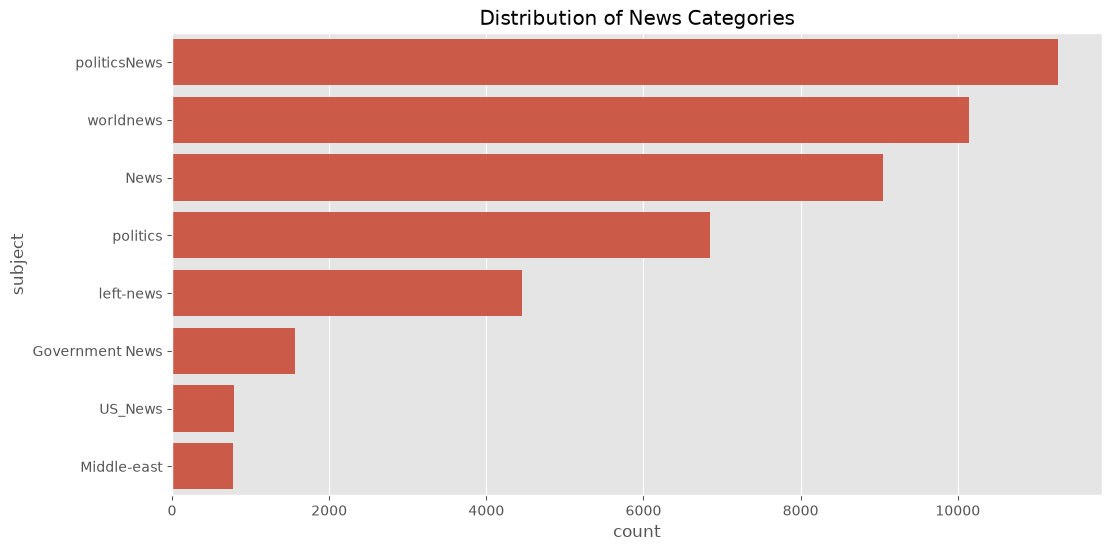

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=news_df,
    y="subject",
    order=news_df["subject"].value_counts().index
)

plt.title("Distribution of News Categories")

plt.show()


In [15]:
news_df["date"].head()

0      February 13, 2017
1         April 5, 2017 
2    September 27, 2017 
3           May 22, 2017
4         June 24, 2016 
Name: date, dtype: str

In [16]:
(news_df["text"].str.strip() == "").sum()

np.int64(631)

In [17]:
(news_df["title"].str.strip() == "").sum()

np.int64(0)

In [18]:
news_df.to_csv("../data/news_dataset.csv", index=False)

print("EDA completed successfully!")

EDA completed successfully!
